# 1. Import all required libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# System
import warnings
import os

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 2. Load Dataset

In [2]:
df1 = pd.read_excel("/kaggle/input/datasets/mahendrapalsaniya/retail-dataset/online_retail_II.xlsx",sheet_name="Year 2009-2010")
df2 = pd.read_excel("/kaggle/input/datasets/mahendrapalsaniya/retail-dataset/online_retail_II.xlsx",sheet_name="Year 2010-2011")

In [3]:
df = pd.concat([df1,df2], ignore_index=True)

print('Sheet 1 rows', df1.shape[0])
print('Sheet 2 rows', df2.shape[0])
print('Combined rows', df.shape[0])

print('Columns', list(df.columns))

Sheet 1 rows 525461
Sheet 2 rows 541910
Combined rows 1067371
Columns ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


In [5]:
# Dataset Information 
print("======== BASIC INFORMATION ==========")
print(df.info())
print("======== BASIC STATISTICS ==========")
print(df.describe())

======== BASIC INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB
None
======== BASIC STATISTICS ==========
        Quantity                    InvoiceDate      Price  Customer ID
count 1067371.00                        1067371 1067371.00    824364.00
mean        9.94  2011-01-02 21:13:55.394028544       4.65     15324.64


# 3. Data Cleaning

In [6]:
# missing Values
print("Missing Values: ")
print(df.isnull().sum())
print()

#missing percentage
print("Missing Percentage: ")
print(round(df.isnull().sum()/len(df)*100,2))

Missing Values: 
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Missing Percentage: 
Invoice        0.00
StockCode      0.00
Description    0.41
Quantity       0.00
InvoiceDate    0.00
Price          0.00
Customer ID   22.77
Country        0.00
dtype: float64


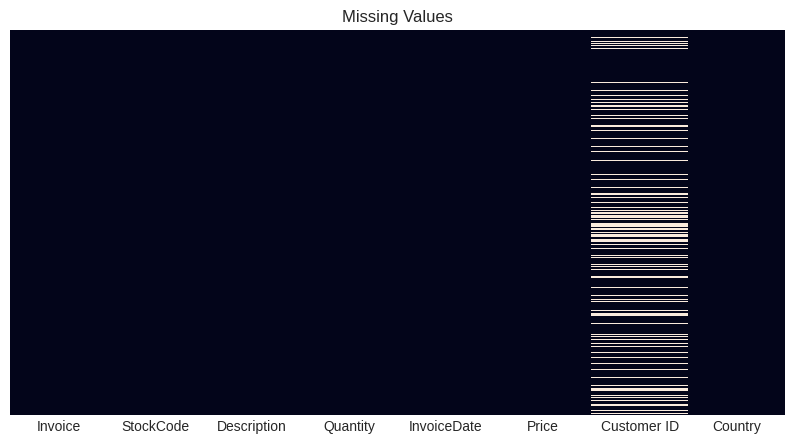

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values")
plt.show()

plt.savefig('missing_values.png', dpi=150)

In [8]:
# Duplicates values

print("Duplicate Values")
print(df.duplicated().sum())

Duplicate Values
34335


In [9]:
#check cancelled orders
cancelled=df[df['Invoice'].astype(str).str.startswith('C')]
print("Cancelled Orders: ", len(cancelled))
print("Sample Cancelled Orders: ")
cancelled.head(3)

Cancelled Orders:  19494
Sample Cancelled Orders: 


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia


In [10]:
# START CLEANING
df_clean = df.copy()
print("Original Rows", len(df))

# Step 1 - Remove missing Customer IDs
df_clean = df_clean.dropna(subset=['Customer ID'])
print("After removing missing Customer ID:", len(df_clean))

# Step 2 - Remove duplicate rows
df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", len(df_clean))

# Step 3 - Remove cancelled orders
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print("After removing cancellations:", len(df_clean))

# Step 4 - Remove negative quantity
df_clean = df_clean[df_clean['Quantity'] > 0]
print("After removing negative quantity:", len(df_clean))

# Step 5 - Remove zero or negative price
df_clean = df_clean[df_clean['Price'] > 0]
print("After removing bad prices:", len(df_clean))

print()
print("Total rows removed:", len(df) - len(df_clean))
print("Clean dataset rows:", len(df_clean))

# fix data types

#fix Customer ID to be string and remove decimal places
df_clean['Customer ID'] = df_clean['Customer ID'].astype(int).astype(str)

#rename columns - remove space for easier coding 
df_clean = df_clean.rename(columns={'Customer ID':'CustomerID'})

#verify
print("Customer ID sample:", df_clean['CustomerID'].head().tolist())
print("Customer ID data type:", df_clean['CustomerID'].dtype)
print()
print("Updated Columns:", list(df_clean.columns))

Original Rows 1067371
After removing missing Customer ID: 824364
After removing duplicates: 797885
After removing cancellations: 779495
After removing negative quantity: 779495
After removing bad prices: 779425

Total rows removed: 287946
Clean dataset rows: 779425
Customer ID sample: ['13085', '13085', '13085', '13085', '13085']
Customer ID data type: object

Updated Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


In [11]:
# Overall KPIS
print("Shape:", df_clean.shape)
print()
print("Missing values:")
print(df_clean.isnull().sum())
print()
print("Data types:")
print(df_clean.dtypes)
print()
print("Date range:")
print("From:", df_clean['InvoiceDate'].min())
print("To:  ", df_clean['InvoiceDate'].max())
print()
print("Unique customers:", df_clean['CustomerID'].nunique())
print("Unique products: ", df_clean['StockCode'].nunique())
print("Unique countries:", df_clean['Country'].nunique())

Shape: (779425, 8)

Missing values:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
dtype: int64

Data types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
CustomerID             object
Country                object
dtype: object

Date range:
From: 2009-12-01 07:45:00
To:   2011-12-09 12:50:00

Unique customers: 5878
Unique products:  4631
Unique countries: 41


In [12]:
#saving clean data 
df_clean.to_csv("/kaggle/working/online_retail_clean.csv", index=False)

print("Clean data saved successfully!")
print("Rows saved:", len(df_clean))

Clean data saved successfully!
Rows saved: 779425


# 4. Feature Engineering

In [13]:
#Creating total revenue
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['Price']

print("\nTotalSales column created!\n")
print("Sample:\n")
print(df_clean[['Invoice', 'Quantity', 'Price', 'TotalSales']].head())
print("\nTotal revenue across all transactions: £", round(df_clean['TotalSales'].sum(), 2))


TotalSales column created!

Sample:

  Invoice  Quantity  Price  TotalSales
0  489434        12   6.95       83.40
1  489434        12   6.75       81.00
2  489434        12   6.75       81.00
3  489434        48   2.10      100.80
4  489434        24   1.25       30.00

Total revenue across all transactions: £ 17374804.27


In [14]:
#Extract Date Features
# Extract useful features from InvoiceDate
df_clean['Year']       = df_clean['InvoiceDate'].dt.year
df_clean['Month']      = df_clean['InvoiceDate'].dt.month
df_clean['Day']        = df_clean['InvoiceDate'].dt.day
df_clean['Hour']       = df_clean['InvoiceDate'].dt.hour
df_clean['DayOfWeek']  = df_clean['InvoiceDate'].dt.dayofweek  # 0=Monday, 6=Sunday
df_clean['Quarter']    = df_clean['InvoiceDate'].dt.quarter
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['IsWeekend']  = (df_clean['InvoiceDate'].dt.dayofweek >= 5).astype(int)

print("Date features created!")
print()
print("Sample:")
print(df_clean[['InvoiceDate', 'Year', 'Month', 'Day', 'Hour',
          'DayOfWeek', 'Quarter','YearMonth', 'IsWeekend']].head())

Date features created!

Sample:
          InvoiceDate  Year  Month  Day  Hour  DayOfWeek  Quarter YearMonth  \
0 2009-12-01 07:45:00  2009     12    1     7          1        4   2009-12   
1 2009-12-01 07:45:00  2009     12    1     7          1        4   2009-12   
2 2009-12-01 07:45:00  2009     12    1     7          1        4   2009-12   
3 2009-12-01 07:45:00  2009     12    1     7          1        4   2009-12   
4 2009-12-01 07:45:00  2009     12    1     7          1        4   2009-12   

   IsWeekend  
0          0  
1          0  
2          0  
3          0  
4          0  


In [15]:
#Create RFM features
#Reference date - 1 day after last transaction in cleaned dataset
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference date for Recency:", reference_date)

# Calculate RFM per customer
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalSales', 'sum')
).reset_index()

print("\nRFM Table created!")
print("Total customers:", len(rfm))
print("\nSample:")
print(rfm.head())
display(rfm.describe().round(2))

Reference date for Recency: 2011-12-10 12:50:00

RFM Table created!
Total customers: 5878

Sample:
  CustomerID  Recency  Frequency  Monetary
0      12346      326         12  77556.46
1      12347        2          8   4921.53
2      12348       75          5   2019.40
3      12349       19          4   4428.69
4      12350      310          1    334.40


,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,2955.90
std,209.34,13.01,14440.85
min,1.00,1.00,2.95
25%,26.00,1.00,342.28
50%,96.00,3.00,867.74
75%,380.00,7.00,2248.30
max,739.00,398.00,580987.04


In [16]:
# Assign RFM Score (1-5 Scale) 
# NOTE: For Recency, lower days = better, so we reverse it
# We divide each metric into 5 equal quintiles
# Score 5 = Best and Score 1 = Worst

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'),q=5,
                         labels=[1,2,3,4,5]).astype(int)

rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5,4,3,2,1],
                         duplicates='drop').astype(int)

rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),q=5,
                        labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = (rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']) / 3
print('\n RFM Score Assigned!')
display(rfm.head())


 RFM Score Assigned!


,CustomerID,Recency,Frequency,Monetary,F_Score,R_Score,M_Score,RFM_Score
0,12346,326,12,77556.46,5,2,5,4.00
1,12347,2,8,4921.53,4,5,5,4.67
2,12348,75,5,2019.40,4,3,4,3.67
3,12349,19,4,4428.69,3,5,5,4.33
4,12350,310,1,334.40,1,2,2,1.67


In [17]:
# Assign Customer Segments based on RFM Score

def assign_seg(score):
    if score >= 4.5:
        return 'Champions'          # Best customers — Recently, spend most
    elif score >= 4.0:
        return 'Loyal Customers'    # Buy regularly and spend well
    elif score >= 3.5:
        return 'Potential Loyalists'# Recent buyers with good frequency
    elif score >= 3.0:
        return 'At Risk'            # Used to buy but haven't recently
    elif score >= 2.0:
        return 'Hibernating'        # Low scores across all dimensions
    else:
        return 'Lost'               # Lowest scores — likely churned

rfm['Segment'] = rfm['RFM_Score'].apply(assign_seg)

# Show segment distribution
seg_counts = rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']

print("Customer segments assigned!")
print("\n📊 Segment Distribution:")
display(seg_counts)

Customer segments assigned!

📊 Segment Distribution:


,Segment,Count
0,Hibernating,1410
1,Lost,1308
2,At Risk,960
3,Loyal Customers,866
4,Champions,858
5,Potential Loyalists,476


In [18]:
# Create daily sales time series:
# Aggregate daily sales - used for for demand forecasting
daily_sales = df_clean.groupby(df_clean['InvoiceDate'].dt.date).agg(
    Revenue      = ('TotalSales', 'sum'),
    Orders       = ('Invoice', 'nunique'),
    Quantity     = ('Quantity', 'sum')
).reset_index()

daily_sales.columns = ['Date', 'Revenue', 'Orders', 'Quantity']
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])
daily_sales = daily_sales.sort_values('Date').reset_index(drop=True)

print("Daily sales time series created!")
print("Total days:", len(daily_sales))
print(f"\nfrom {daily_sales['Date'].min().date()} to {daily_sales['Date'].max().date()} ")
print("Sample:")
display(daily_sales.head())

Daily sales time series created!
Total days: 604

from 2009-12-01 to 2011-12-09 
Sample:


,Date,Revenue,Orders,Quantity
0,2009-12-01,43894.87,98,24335
1,2009-12-02,52762.06,110,29679
2,2009-12-03,67413.62,122,48009
3,2009-12-04,33913.81,80,19954
4,2009-12-05,9803.05,30,5119


In [19]:
# Create Lag Features and Rolling Statistics

# Lag Features : "what was the revenure X days ago" 
# Rolling Stats : "what was the avg over last X days"

daily_sales = daily_sales.sort_values('Date').reset_index(drop=True)

# --- Lag features ---
daily_sales['Revenue_Lag_1']  = daily_sales['Revenue'].shift(1)   # Yesterday
daily_sales['Revenue_Lag_7']  = daily_sales['Revenue'].shift(7)   # 1 week ago
daily_sales['Revenue_Lag_14'] = daily_sales['Revenue'].shift(14)  # 2 weeks ago
daily_sales['Revenue_Lag_30'] = daily_sales['Revenue'].shift(30)  # 1 month ago

# --- Rolling statistics ---
daily_sales['Rolling_Mean_7']  = daily_sales['Revenue'].rolling(window=7).mean()   # 7-day avg
daily_sales['Rolling_Std_7']   = daily_sales['Revenue'].rolling(window=7).std()    # 7-day volatility
daily_sales['Rolling_Mean_30'] = daily_sales['Revenue'].rolling(window=30).mean()  # 30-day avg

# --- Date features ---
daily_sales['DayOfWeek']  = daily_sales['Date'].dt.dayofweek    # 0=Mon, 6=Sun
daily_sales['Month']      = daily_sales['Date'].dt.month         # 1-12
daily_sales['Quarter']    = daily_sales['Date'].dt.quarter       # 1-4
daily_sales['IsWeekend']  = (daily_sales['DayOfWeek'] >= 5).astype(int)  # 1 if weekend

print("✅ Lag features and rolling statistics created!")
print(f"\n📋 New columns added:")
new_cols = ['Revenue_Lag_1','Revenue_Lag_7','Revenue_Lag_14','Revenue_Lag_30',
            'Rolling_Mean_7','Rolling_Std_7','Rolling_Mean_30',
            'DayOfWeek','Month','Quarter','IsWeekend']
for col in new_cols:
    print(f"   → {col}")

✅ Lag features and rolling statistics created!

📋 New columns added:
   → Revenue_Lag_1
   → Revenue_Lag_7
   → Revenue_Lag_14
   → Revenue_Lag_30
   → Rolling_Mean_7
   → Rolling_Std_7
   → Rolling_Mean_30
   → DayOfWeek
   → Month
   → Quarter
   → IsWeekend


In [20]:
# We define "churned" as a customer who hasn't bought
# in the last 90 days of the dataset period

# Last purchase date per customer
last_purchase = df_clean.groupby('CustomerID')['InvoiceDate'].max().reset_index()
last_purchase.columns = ['CustomerID', 'LastPurchase']

# Dataset end date
end_date = df_clean['InvoiceDate'].max()

# If last purchase was more than 90 days before end → churned = 1
last_purchase['DaysSinceLastPurchase'] = (end_date - last_purchase['LastPurchase']).dt.days
last_purchase['Churned'] = (last_purchase['DaysSinceLastPurchase'] > 90).astype(int)

# Merge churn label into RFM dataframe
rfm = rfm.merge(last_purchase[['CustomerID', 'Churned']], on='CustomerID', how='left')

# Show churn distribution
churn_dist = rfm['Churned'].value_counts()
print("✅ Churn labels created!")
print(f"\n📊 Churn Distribution:")
print(f"   Not Churned (0): {churn_dist[0]:,} customers ({churn_dist[0]/len(rfm)*100:.1f}%)")
print(f"   Churned     (1): {churn_dist[1]:,} customers ({churn_dist[1]/len(rfm)*100:.1f}%)")

✅ Churn labels created!

📊 Churn Distribution:
   Not Churned (0): 2,893 customers (49.2%)
   Churned     (1): 2,985 customers (50.8%)


In [21]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalSales,Year,Month,Day,Hour,DayOfWeek,Quarter,YearMonth,IsWeekend
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009,12,1,7,1,4,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,1,7,1,4,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009,12,1,7,1,4,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009,12,1,7,1,4,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009,12,1,7,1,4,2009-12,0


In [22]:
#Save all feature files:
# Save RFM features
rfm.to_csv("/kaggle/working/rfm_features.csv", index=False)

# Save daily sales
daily_sales.to_csv("/kaggle/working/daily_sales.csv", index=False)

# Save final engineered dataset
df_clean.to_csv("/kaggle/working/retail_featured.csv", index=False)

print("All files saved successfully!\n")

print("Files created:\n")
print("  rfm_features.csv        ->", len(rfm), "customers")
print("  daily_sales.csv         ->", len(daily_sales), "days")
print("  retail_featured.csv     ->", len(df_clean), "rows")

All files saved successfully!

Files created:

  rfm_features.csv        -> 5878 customers
  daily_sales.csv         -> 604 days
  retail_featured.csv     -> 779425 rows


# 5. EDA (Exploratory data analysis)

### 1. Monthly revenue trend

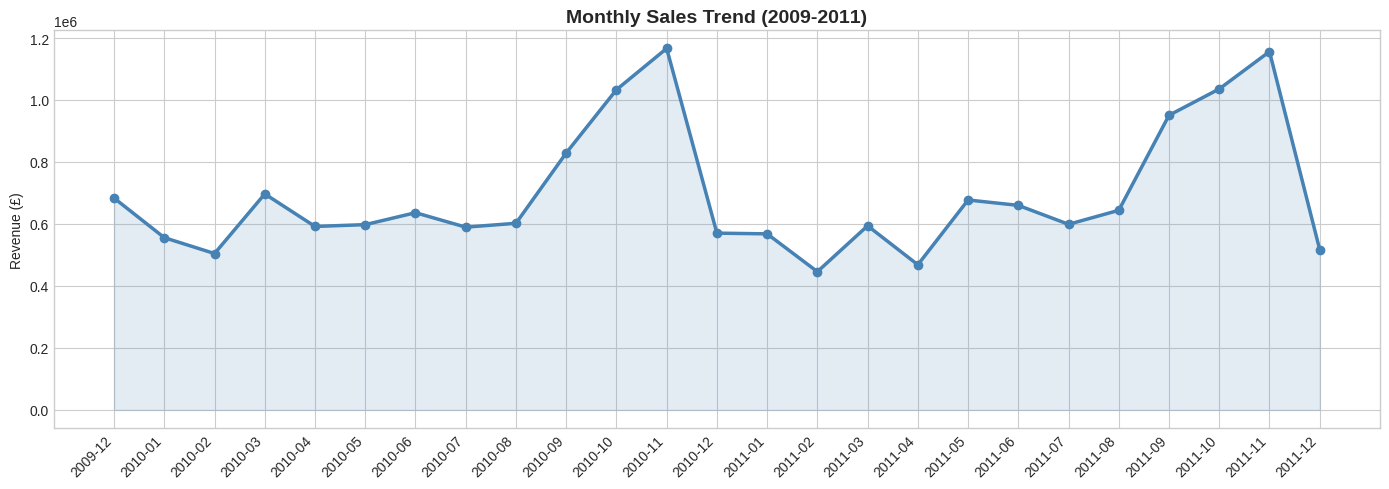

Peak month: 2010-11
Peak revenue: £ 1166460.02
Lowest month: 2011-02
Lowest revenue: £ 446084.92


In [23]:
# Monthly revenue trend
monthly = df_clean.groupby(['Year', 'Month'])['TotalSales'].sum().reset_index()
monthly['YearMonth'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly['YearMonth'], monthly['TotalSales'], 
         marker='o', color='steelblue', linewidth=2.5, markersize=6)
plt.fill_between(range(len(monthly)), monthly['TotalSales'],
                 alpha=0.15, color='steelblue')
plt.xticks(range(len(monthly)), monthly['YearMonth'], rotation=45, ha='right')
plt.title('Monthly Sales Trend (2009-2011)', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('EDA_Monthly_Sales.png', dpi=150)
plt.show()

print("Peak month:", monthly.loc[monthly['TotalSales'].idxmax(), 'YearMonth'])
print("Peak revenue: £", round(monthly['TotalSales'].max(), 2))
print("Lowest month:", monthly.loc[monthly['TotalSales'].idxmin(), 'YearMonth'])
print("Lowest revenue: £", round(monthly['TotalSales'].min(), 2))


### 2. Top 10 Countries by Revenue

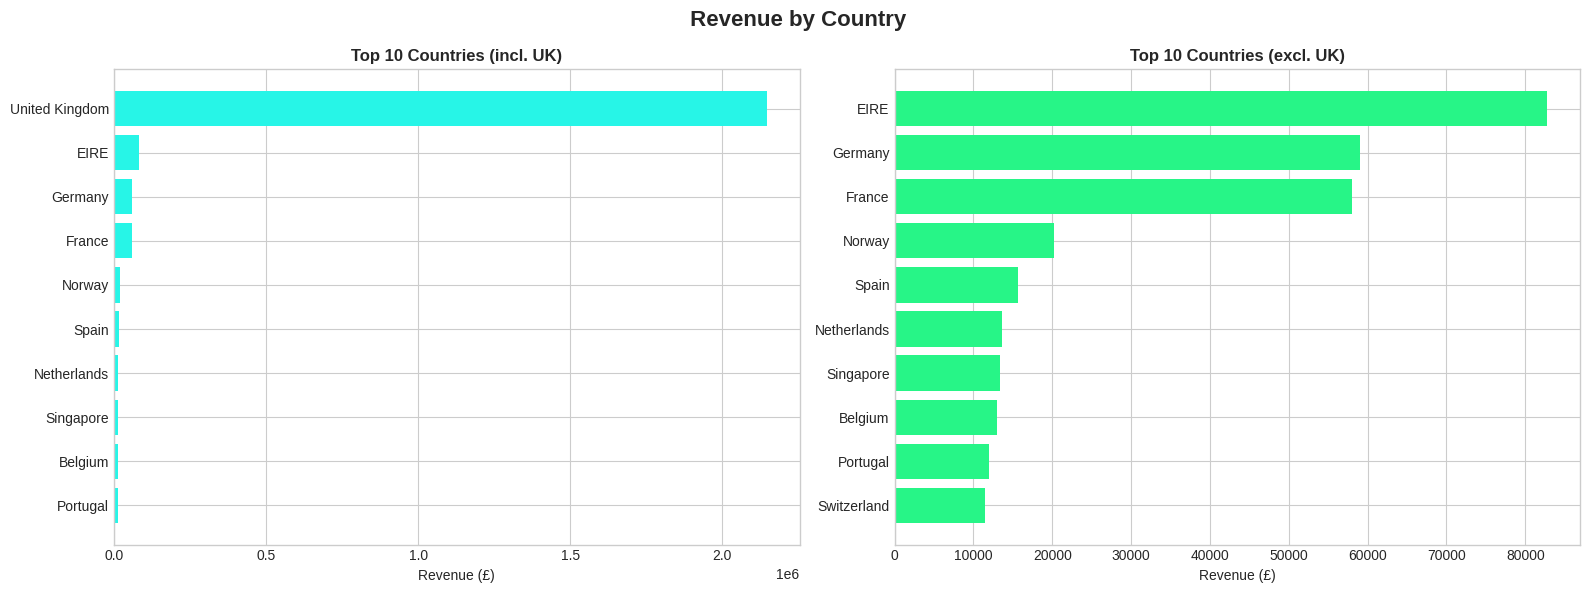

In [24]:
# Top 10 Countries by Revenue

# Group by country
country_sales = df_clean.groupby('Country')['Price'].sum().reset_index()
country_sales = country_sales.sort_values('Price', ascending=False)

# Exclude UK as it dominates — show rest separately
uk_sales = country_sales[country_sales['Country'] == 'United Kingdom']
top10_ex_uk = country_sales[country_sales['Country'] != 'United Kingdom'].head(10)

# Plot top 10 excluding UK
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — all countries including UK
axes[0].barh(
    country_sales.head(10)['Country'],
    country_sales.head(10)['Price'],
    color='#27F5E7'
)
axes[0].set_title('Top 10 Countries (incl. UK)', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].invert_yaxis()

# Right — excluding UK to see others clearly
axes[1].barh(
    top10_ex_uk['Country'],
    top10_ex_uk['Price'],
    color='#27F587'
)
axes[1].set_title('Top 10 Countries (excl. UK)', fontweight='bold')
axes[1].set_xlabel('Revenue (£)')
axes[1].invert_yaxis()

plt.suptitle(' Revenue by Country', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_top_countries.png', dpi=150)
plt.show()


### 3. Revenue by dat of week

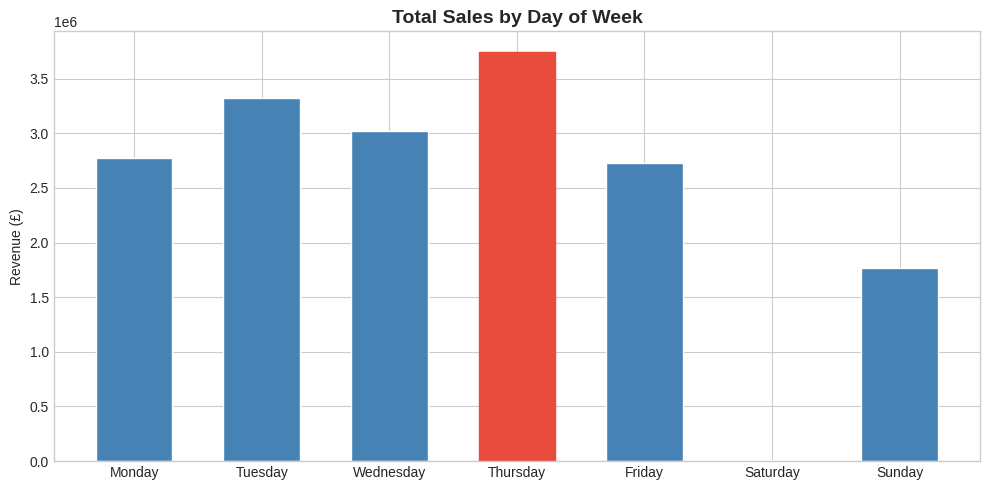

Revenue by day:
  Monday       £2,778,201.57
  Tuesday      £3,322,830.14
  Wednesday    £3,021,043.85
  Thursday     £3,745,783.43
  Friday       £2,728,473.17
  Saturday     £    9,803.05
  Sunday       £1,768,669.05


In [25]:
# Revenue by day of week
day_names = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 
             3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}

dow = df_clean.groupby('DayOfWeek')['TotalSales'].sum().reset_index()
dow['DayName'] = dow['DayOfWeek'].map(day_names)

plt.figure(figsize=(10, 5))
bars = plt.bar(dow['DayName'], dow['TotalSales'], 
               color='steelblue', edgecolor='white', width=0.6)

# Highlight highest bar
max_idx = dow['TotalSales'].idxmax()
bars[max_idx].set_color('#e74c3c')

plt.title('Total Sales by Day of Week', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('EDA_day_of_week.png', dpi=150)
plt.show()

print("Revenue by day:")
for _, row in dow.iterrows():
    print(f"  {row['DayName']:<12} £{row['TotalSales']:>12,.2f}")

### 4. Customer Segments

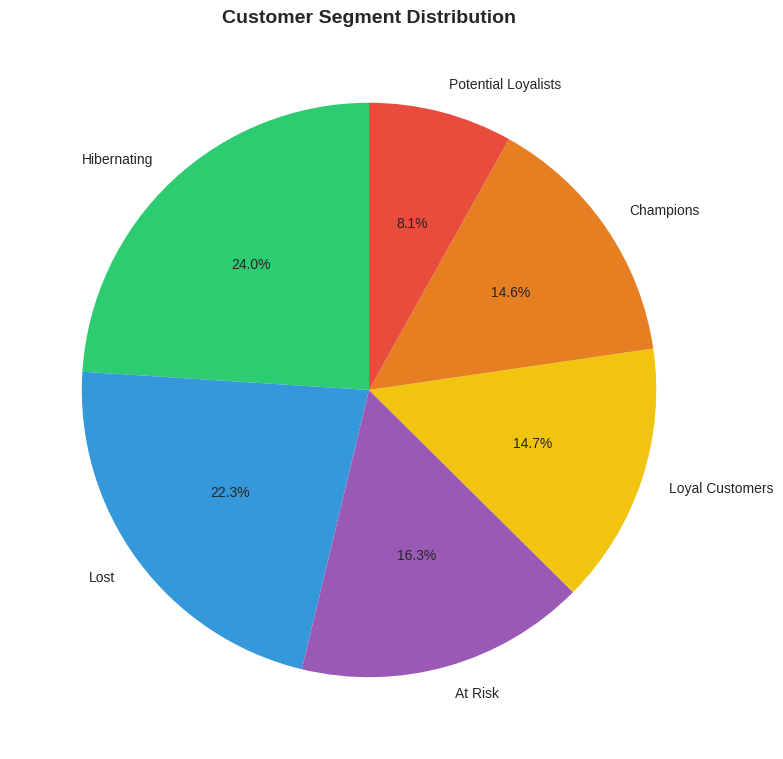

Segments:
 Segment
Hibernating            1410
Lost                   1308
At Risk                 960
Loyal Customers         866
Champions               858
Potential Loyalists     476
Name: count, dtype: int64


In [26]:
# Segment customers based on RFM total score

seg_counts = rfm['Segment'].value_counts()
colors = ['#2ecc71','#3498db','#9b59b6','#f1c40f','#e67e22','#e74c3c']

plt.figure(figsize=(8, 8))
plt.pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_customer_segments.png', dpi=150)
plt.show()
print("Segments:\n",seg_counts)

### 5. Top 10 products by revenue 

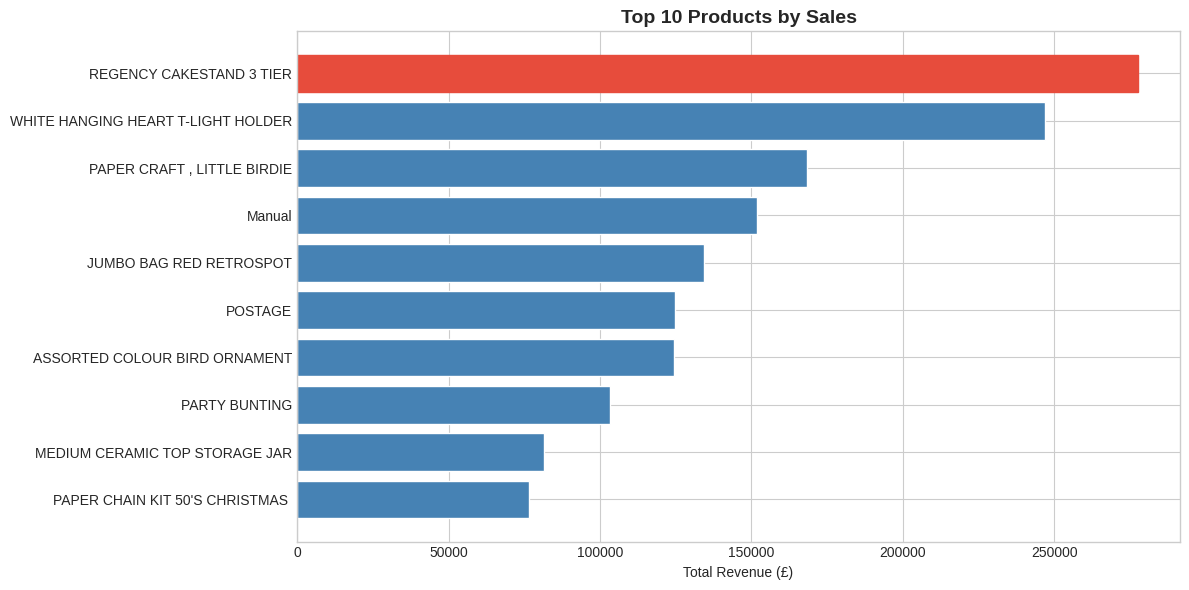

Top 5 products:
  REGENCY CAKESTAND 3 TIER                      £277,656.25
  WHITE HANGING HEART T-LIGHT HOLDER            £247,048.01
  PAPER CRAFT , LITTLE BIRDIE                   £168,469.60
  Manual                                        £151,777.67
  JUMBO BAG RED RETROSPOT                       £134,307.44


In [27]:
# Top 10 products by revenue
top_products = df_clean.groupby('Description')['TotalSales'].sum()\
                 .sort_values(ascending=True).tail(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_products.index, top_products.values, 
                color='steelblue', edgecolor='white')
bars[-1].set_color('#e74c3c')  # highlight top product

plt.title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('EDA_top_products.png', dpi=150)
plt.show()

print("Top 5 products:")
top5 = df_clean.groupby('Description')['TotalSales'].sum()\
.sort_values(ascending=False).head()
for prod, rev in top5.items():
    print(f"  {prod:<45} £{rev:>10,.2f}")

### 6. RFM Distribution

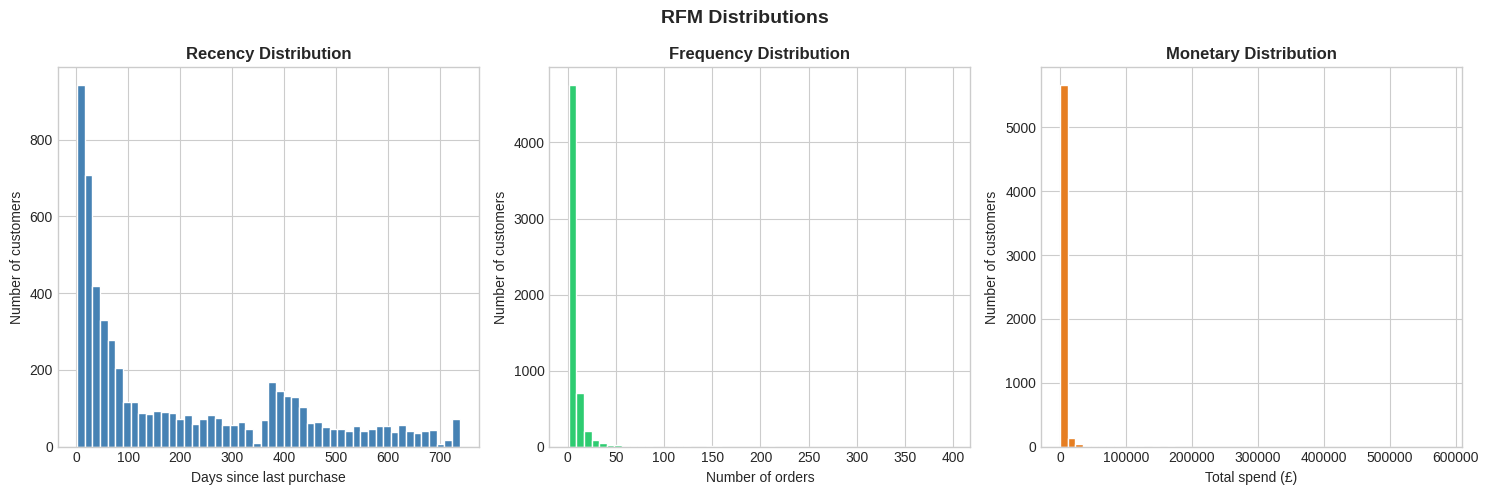

RFM Statistics:
       Recency  Frequency  Monetary
count  5878.00    5878.00   5878.00
mean    201.33       6.29   2955.90
std     209.34      13.01  14440.85
min       1.00       1.00      2.95
25%      26.00       1.00    342.28
50%      96.00       3.00    867.74
75%     380.00       7.00   2248.30
max     739.00     398.00 580987.04


In [28]:
#RMF Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency
axes[0].hist(rfm['Recency'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Recency Distribution', fontweight='bold')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of customers')

# Frequency
axes[1].hist(rfm['Frequency'], bins=50, color='#2ecc71', edgecolor='white')
axes[1].set_title('Frequency Distribution', fontweight='bold')
axes[1].set_xlabel('Number of orders')
axes[1].set_ylabel('Number of customers')

# Monetary
axes[2].hist(rfm['Monetary'], bins=50, color='#e67e22', edgecolor='white')
axes[2].set_title('Monetary Distribution', fontweight='bold')
axes[2].set_xlabel('Total spend (£)')
axes[2].set_ylabel('Number of customers')

plt.suptitle('RFM Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_rfm_distributions.png', dpi=150)
plt.show()

print("RFM Statistics:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

### 7. Revenue by hour of day

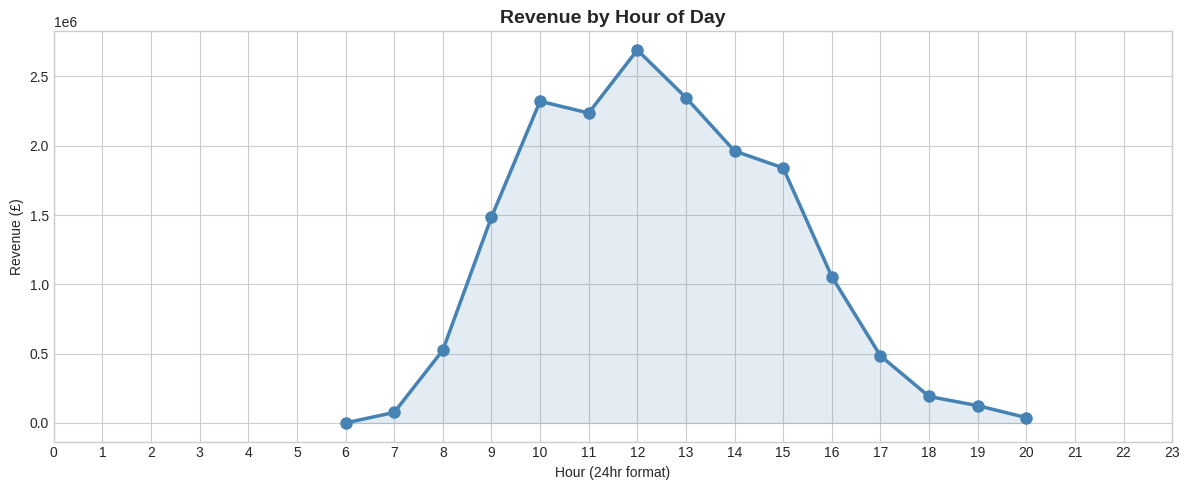

Peak hour: 12 :00
Lowest hour: 6 :00


In [29]:
# Revenue by hour of day
hourly = df_clean.groupby('Hour')['TotalSales'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly['Hour'], hourly['TotalSales'], 
         marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.fill_between(hourly['Hour'], hourly['TotalSales'], 
                 alpha=0.15, color='steelblue')
plt.xticks(range(0, 24))
plt.title('Revenue by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour (24hr format)')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.savefig('EDA_hourly_sales.png', dpi=150)
plt.show()

print("Peak hour:", hourly.loc[hourly['TotalSales'].idxmax(), 'Hour'], ":00")
print("Lowest hour:", hourly.loc[hourly['TotalSales'].idxmin(), 'Hour'], ":00")

### 8. Quarterly revenue

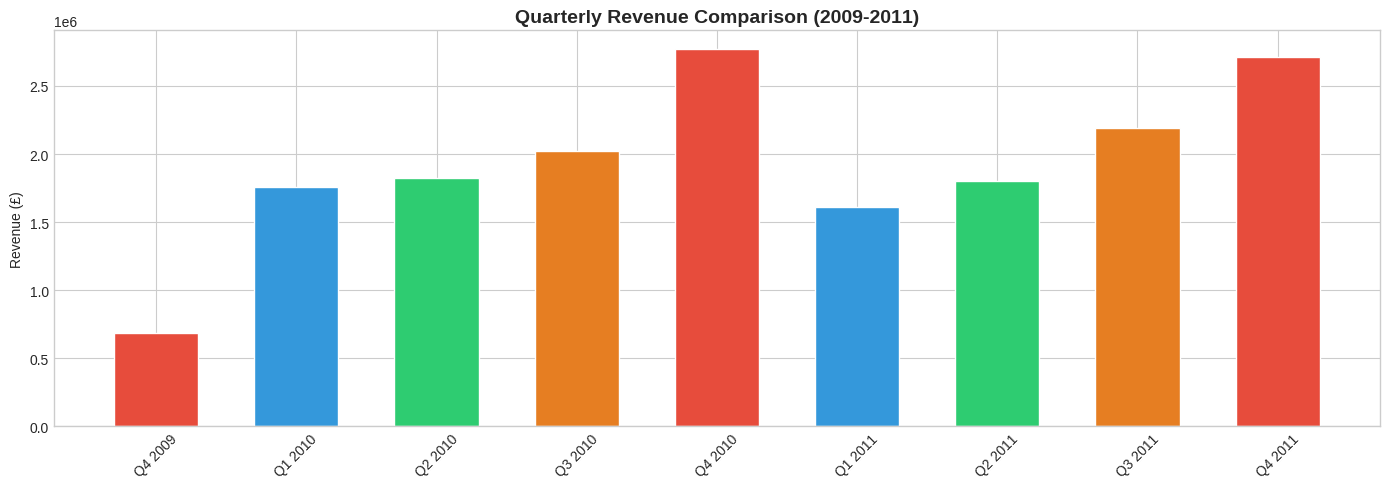

Quarterly Revenue:
  Q4 2009    £  683,504.01
  Q1 2010    £1,757,340.10
  Q2 2010    £1,826,186.51
  Q3 2010    £2,020,974.72
  Q4 2010    £2,769,994.76
  Q1 2011    £1,608,267.99
  Q2 2011    £1,805,775.53
  Q3 2011    £2,193,704.14
  Q4 2011    £2,709,056.50


In [30]:
# Quarterly revenue
quarterly = df_clean.groupby(['Year', 'Quarter'])['TotalSales'].sum().reset_index()
quarterly['Label'] = 'Q' + quarterly['Quarter'].astype(str) + ' ' + quarterly['Year'].astype(str)

colors = ['#3498db','#2ecc71','#e67e22','#e74c3c']
quarter_colors = [colors[q-1] for q in quarterly['Quarter']]

plt.figure(figsize=(14, 5))
bars = plt.bar(quarterly['Label'], quarterly['TotalSales'],
               color=quarter_colors, edgecolor='white', width=0.6)
plt.title('Quarterly Revenue Comparison (2009-2011)', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('EDA_quarterly_revenue.png', dpi=150)
plt.show()

print("Quarterly Revenue:")
for _, row in quarterly.iterrows():
    print(f"  {row['Label']:<10} £{row['TotalSales']:>12,.2f}")

### 9. Churn Distribution

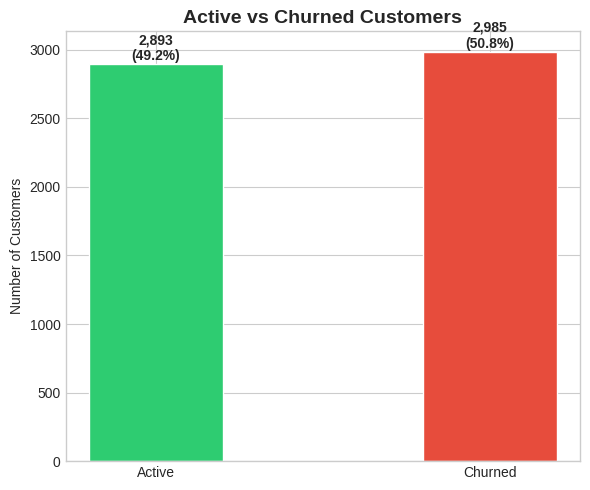

In [31]:
# Churn bar chart
plt.figure(figsize=(6, 5))
labels = ['Active', 'Churned']
values = [len(rfm[rfm['Churned']==0]), len(rfm[rfm['Churned']==1])]
colors = ['#2ecc71', '#e74c3c']

bars = plt.bar(labels, values, color=colors, width=0.4, edgecolor='white')
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(rfm)*100:.1f}%)',
             ha='center', fontweight='bold')

plt.title('Active vs Churned Customers', fontsize=14, fontweight='bold')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('EDA_churn_distribution.png', dpi=150)
plt.show()

### 10. Revenue with Rolling Averages

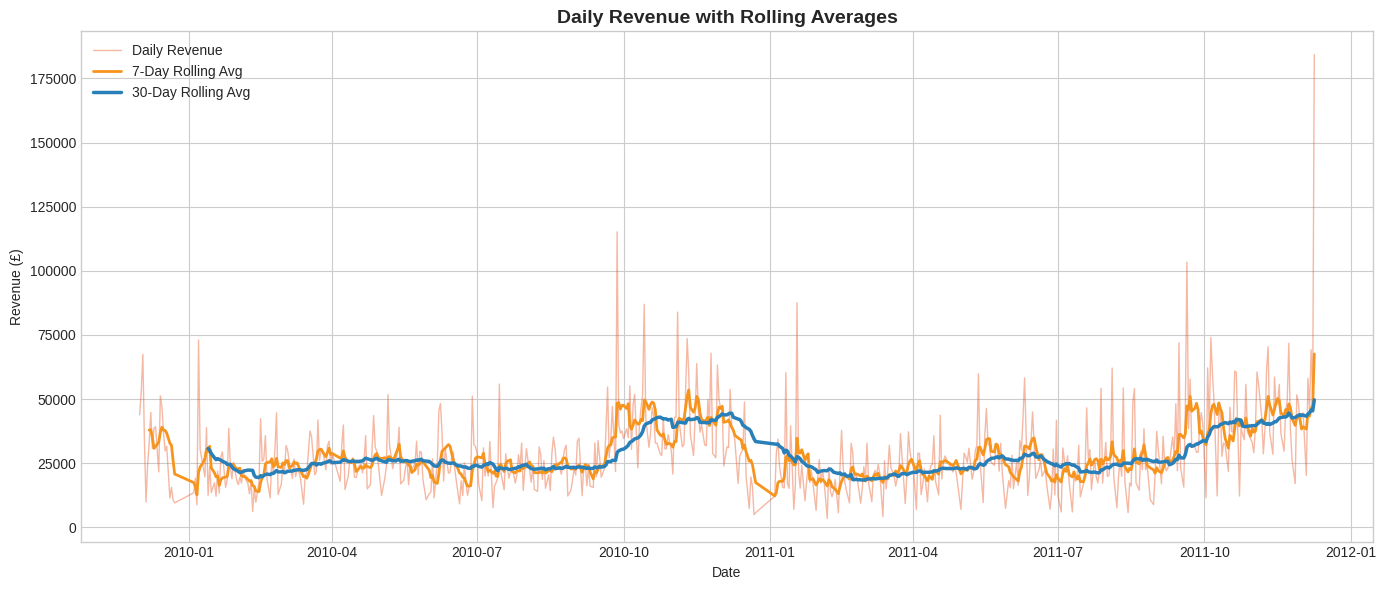

In [32]:
# Visualize Revenue with Rolling Averages

fig, ax = plt.subplots(figsize=(14, 6))

# Actual daily revenue
ax.plot(daily_sales['Date'], daily_sales['Revenue'],
        color='#E84E1B', alpha=0.4, linewidth=1, label='Daily Revenue')

# 7-day rolling average
ax.plot(daily_sales['Date'], daily_sales['Rolling_Mean_7'],
        color='#F7941D', linewidth=2, label='7-Day Rolling Avg')

# 30-day rolling average
ax.plot(daily_sales['Date'], daily_sales['Rolling_Mean_30'],
        color='#2980B9', linewidth=2.5, label='30-Day Rolling Avg')

ax.set_title('Daily Revenue with Rolling Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.legend()
plt.tight_layout()
plt.savefig('EDA_rolling_averages.png', dpi=150)
plt.show()